# Music Genre Classification

Klasifikacija muzičkih žanrova korišćenjem log-Mel spektrograma, klasičnih modela, FCNN i kombinovanog CNN + FCNN pristupa.

## OSNOVNE BIBLIOTEKE

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## AUDIO

In [2]:
import librosa

## SCIKIT-LEARN

In [3]:
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

## PYTORCH

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    TensorDataset,
    Dataset,
    DataLoader
)
# print("PyTorch:", torch.__version__)
# print("CUDA:", torch.cuda.is_available())
# print("NumPy:", np.__version__)
# print("Pandas:", pd.__version__)
# print("Librosa:", librosa.__version__)
# print("Scikit-learn:", sklearn.__version__)

# Putanja do GTZAN skupa podataka

In [5]:

from pathlib import Path

data_path = Path("Data/genres_original")

print(list(data_path.iterdir()))

# Funkcija učitava audio zapis i pretvara ga u log-Mel spektrogram

[WindowsPath('Data/genres_original/blues'), WindowsPath('Data/genres_original/classical'), WindowsPath('Data/genres_original/country'), WindowsPath('Data/genres_original/disco'), WindowsPath('Data/genres_original/hiphop'), WindowsPath('Data/genres_original/jazz'), WindowsPath('Data/genres_original/metal'), WindowsPath('Data/genres_original/pop'), WindowsPath('Data/genres_original/reggae'), WindowsPath('Data/genres_original/rock')]


c:\Users\Andrija\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(128, 1293)


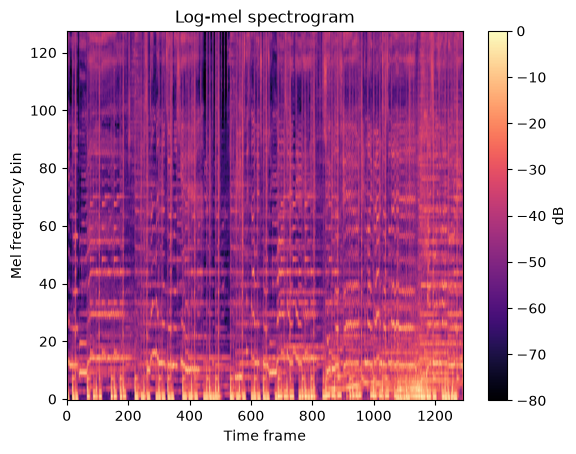

In [6]:
def compute_log_mel_spectrogram(
    audio_path,
    sr=22050,
    n_fft=2048,
    hop_length=512,
    n_mels=128
):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    return librosa.power_to_db(S, ref=np.max)


def plot_log_mel_spectrogram(log_S):
    plt.imshow(
        log_S,
        origin="lower",
        aspect="auto",
        cmap="magma"
    )
    plt.colorbar(label="dB")
    plt.xlabel("Time frame")
    plt.ylabel("Mel frequency bin")
    plt.title("Log-mel spectrogram")
    plt.show()

# Prikaz log-Mel spektrograma jedne pesme iz pop žanra
file_path = next((data_path / "pop").glob("*.wav"))

log_S = compute_log_mel_spectrogram(file_path)

print(log_S.shape)

plot_log_mel_spectrogram(log_S)


# Za svaki audio zapis čuvamo putanju, žanr, oznaku klase i spektrogram

In [7]:
def create_music_dataset(genres=("pop", "rock")):
    records = []
    skipped = []

    for label, genre in enumerate(genres):
        genre_path = data_path / genre

        for file_path in genre_path.glob("*.wav"):
            try:
                spectrogram = compute_log_mel_spectrogram(file_path)

                records.append({
                    "file": str(file_path),
                    "genre": genre,
                    "label": label,
                    "spectrogram": spectrogram
                })

            except Exception as e:
                print(f"Skipping {file_path}: {e}")
                skipped.append(str(file_path))

    print(f"Loaded {len(records)} files.")
    print(f"Skipped {len(skipped)} files.")

    return pd.DataFrame(records), skipped


genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

df, skipped = create_music_dataset(genres)

print(df.head())

Skipping Data\genres_original\jazz\jazz.00054.wav: Error opening 'Data\\genres_original\\jazz\\jazz.00054.wav': Format not recognised.
Loaded 999 files.
Skipped 1 files.
                                         file  genre  label  \
0  Data\genres_original\blues\blues.00000.wav  blues      0   
1  Data\genres_original\blues\blues.00001.wav  blues      0   
2  Data\genres_original\blues\blues.00002.wav  blues      0   
3  Data\genres_original\blues\blues.00003.wav  blues      0   
4  Data\genres_original\blues\blues.00004.wav  blues      0   

                                         spectrogram  
0  [[-33.945583, -32.846584, -35.507214, -39.4054...  
1  [[-34.54153, -29.19846, -19.021961, -15.642323...  
2  [[-34.202038, -36.66347, -40.07487, -39.533894...  
3  [[-28.885906, -32.159485, -38.439735, -40.5843...  
4  [[-57.91653, -54.47351, -53.03388, -50.900856,...  


In [8]:
print("\nBroj pesama po žanru:")
print(df["genre"].value_counts())

print("\nDimenzija dataseta:")
print(df.shape)

print("\nBroj preskočenih fajlova:")
print(len(skipped))



# Spektrogrami mogu imati različit broj vremenskih frejmova


Broj pesama po žanru:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
reggae       100
pop          100
rock         100
jazz          99
Name: count, dtype: int64

Dimenzija dataseta:
(999, 4)

Broj preskočenih fajlova:
1


In [9]:
def fix_spectrogram_shape(S, target_frames=1293):
    if S.shape[1] > target_frames:
        return S[:, :target_frames]
    elif S.shape[1] < target_frames:
        pad_width = target_frames - S.shape[1]
        return np.pad(
    S,
    ((0, 0), (0, pad_width)),
    mode="constant",
    constant_values=S.min()
)
    else:
        return S

df["spectrogram_fixed"] = df["spectrogram"].apply(fix_spectrogram_shape)

print(df["spectrogram_fixed"].iloc[0].shape)

# Koristimo 70% podataka za trening, 15% za validaciju i 15% za testiranje.

(128, 1293)


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

X_train = np.stack(train_df["spectrogram_fixed"].values)
X_val = np.stack(val_df["spectrogram_fixed"].values)
X_test = np.stack(test_df["spectrogram_fixed"].values)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

# Standardizacija podataka
# Scaler se fituje samo na train skupu kako ne bi došlo do curenja informacija
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Bazni linearni model za poređenje sa složenijim metodama

Train: (699, 165504)
Validation: (150, 165504)
Test: (150, 165504)


In [11]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

y_val_pred = logistic_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

y_test_pred = logistic_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", lr_accuracy)

# Isprobavamo više vrednosti parametra C i biramo onu
# koja daje najbolju tačnost na validation skupu

Validation Accuracy: 0.58
Test Accuracy: 0.4866666666666667


## SUPPORT VECTOR MACHINE

In [12]:
best_svm = None
best_val_acc = 0

for C in [10, 100]:
    svm_model = SVC(kernel="rbf", C=C, random_state=42)
    svm_model.fit(X_train, y_train)

    y_val_pred = svm_model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    print("C =", C, "Validation Accuracy =", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_svm = svm_model

y_test_pred = best_svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", svm_accuracy)

    

C = 10 Validation Accuracy = 0.5866666666666667
C = 100 Validation Accuracy = 0.5866666666666667
Test Accuracy: 0.5066666666666667


## PRIPREMA PODATAKA ZA FCNN

In [13]:
# Spljoštene log-Mel spektrograme pretvaramo u PyTorch tenzore
# Formiraju se posebni train, validation i test skupovi

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Kreiranje TensorDataset objekata

In [14]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#DataLoader

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## FCNN MODEL

In [16]:
class MusicClassifier(nn.Module):  
    def __init__(self, input_size, number_of_classes=10):  
        super(MusicClassifier, self).__init__()  
  
        self.fc1 = nn.Linear(input_size, 512) 
        self.bn1 = nn.BatchNorm1d(512) 
 
        self.fc2 = nn.Linear(512, 512) 
        self.bn2 = nn.BatchNorm1d(512) 
 
        self.fc3 = nn.Linear(512, 512) 
        self.bn3 = nn.BatchNorm1d(512) 
 
        self.fc4 = nn.Linear(512, number_of_classes) 
  
        self.relu = nn.ReLU()  
        self.softmax = nn.Softmax(dim=1)  
  
    def forward(self, x):  
        x = self.fc1(x) 
        x = self.bn1(x) 
        x = self.relu(x) 
 
        x = self.fc2(x) 
        x = self.bn2(x) 
        x = self.relu(x) 
 
        x = self.fc3(x) 
        x = self.bn3(x) 
        x = self.relu(x) 
 
        logits = self.fc4(x) 
        probs = self.softmax(logits) 
 
        return probs, logits

## Izbor uređaja za treniranje: GPU ako je dostupan, inače CPU

In [17]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs, labels = next(iter(train_loader))

input_size = inputs.shape[1]
number_of_classes = len(np.unique(y_train))

print("Input size:", input_size)
print("Number of classes:", number_of_classes)

model = MusicClassifier(input_size, number_of_classes)
model = model.to(get_device())

print(model)

Input size: 165504
Number of classes: 10
MusicClassifier(
  (fc1): Linear(in_features=165504, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc4): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

## TRENIRANJE FCNN MODELA

In [19]:
from tqdm import tqdm


def train_model(model, optimizer, number_of_epochs, train_loader, validation_loader):

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_steps': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_steps': [],
    }

    device = get_device()
    training_step = 0

    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    pbar = tqdm(total=number_of_epochs, desc="Training Progress")
    pbar.set_postfix({"loss": -1, "accuracy": -1})

    for epoch in range(number_of_epochs):

        model.train()

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            probs, logits = model(inputs)

            loss = nn.functional.cross_entropy(logits, labels)

            predicted = torch.argmax(probs, dim=1)
            correct = (predicted == labels).sum().item()
            accuracy = correct / labels.size(0)

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(accuracy)
            metrics['train_steps'].append(training_step)

            training_step += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():

            val_loss = 0
            val_correct = 0
            val_samples = 0

            for inputs, labels in validation_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                probs, logits = model(inputs)

                loss = nn.functional.cross_entropy(
                    logits,
                    labels,
                    reduction='sum'
                )

                val_loss += loss.item()

                predicted = torch.argmax(probs, dim=1)

                val_correct += (predicted == labels).sum().item()
                val_samples += labels.size(0)

            val_loss /= val_samples
            val_accuracy = val_correct / val_samples

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1

            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

        metrics['val_loss'].append(val_loss)
        metrics['val_accuracy'].append(val_accuracy)
        metrics['val_steps'].append(training_step)

        pbar.set_postfix({
            "loss": val_loss,
            "accuracy": val_accuracy
        })

        pbar.update(1)

    pbar.close()

    model.load_state_dict(best_model_state)

    print("\nBest validation accuracy:", best_val_accuracy)
    print("Best epoch:", best_epoch)

    return metrics


def plot_metrics(metrics):

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)

    plt.plot(
        metrics['train_steps'],
        metrics['train_loss'],
        label='Train Loss'
    )

    plt.plot(
        metrics['val_steps'],
        metrics['val_loss'],
        label='Validation Loss'
    )

    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(
        metrics['train_steps'],
        metrics['train_accuracy'],
        label='Train Accuracy'
    )

    plt.plot(
        metrics['val_steps'],
        metrics['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()


def evaluate_fcnn(model, dataloader):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    predicted_labels = []
    true_labels = []

    device = get_device()

    with torch.no_grad():

        for inputs, labels in dataloader:

            inputs, labels = inputs.to(device), labels.to(device)

            probs, logits = model(inputs)

            total_loss += nn.functional.cross_entropy(
                logits,
                labels
            ).item()

            predicted = torch.argmax(probs, dim=1)

            predicted_labels.extend(predicted.squeeze().tolist())
            true_labels.extend(labels.tolist())

            total_samples += labels.size(0)
            total_correct += (predicted.squeeze() == labels).sum().item()

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    precision, recall, f1_score, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='weighted'
    )

    print("FCNN Test Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1_score:.4f}")

    cm = confusion_matrix(
        true_labels,
        predicted_labels
    )

    sns.heatmap(cm, annot=True, fmt='d')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("FCNN Confusion Matrix")
    plt.show()

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

In [20]:
metrics = train_model(
    model,
    optimizer,
    number_of_epochs=100,
    train_loader=train_loader,
    validation_loader=validation_loader
)

Training Progress: 100%|██████████| 100/100 [17:23<00:00, 10.43s/it, loss=1.49, accuracy=0.5] 


Best validation accuracy: 0.6066666666666667
Best epoch: 17


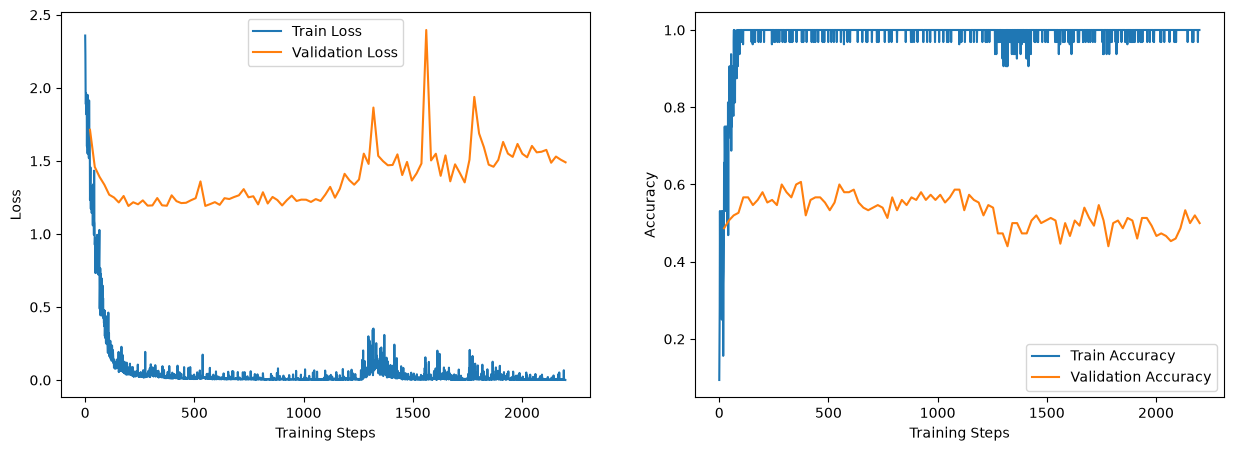

In [21]:
plot_metrics(metrics)

## EVALUACIJA FCNN MODELA

FCNN Test Results:
Accuracy:  0.5533
Precision: 0.5451
Recall:    0.5533
F1 Score:  0.5439


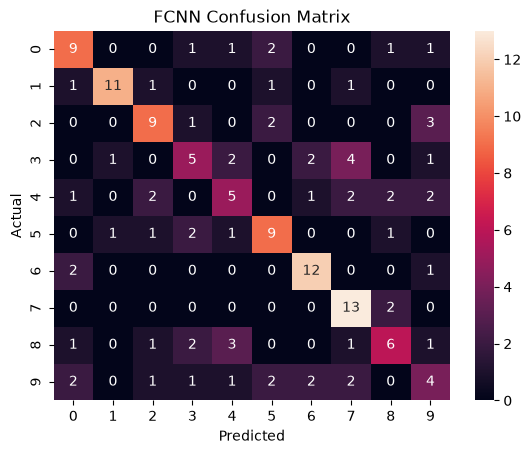

In [22]:
_, fcnn_accuracy = evaluate_fcnn(model, test_loader)

In [23]:
# print(np.stack(train_df["spectrogram_fixed"].values).shape)
# print(train_df["spectrogram_fixed"].iloc[0].shape)

In [24]:
# IZDVAJANJE AUDIO KARAKTERISTIKA ZA CNN + FCNN
def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    features = []

    zcr = librosa.feature.zero_crossing_rate(y)
    features.extend([
        np.mean(zcr),
        np.median(zcr),
        np.std(zcr)
    ])

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.extend([
        np.mean(spectral_centroid),
        np.median(spectral_centroid),
        np.std(spectral_centroid)
    ])

    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features.extend([
        np.mean(spectral_contrast),
        np.median(spectral_contrast),
        np.std(spectral_contrast)
    ])

    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.extend([
        np.mean(spectral_bandwidth),
        np.median(spectral_bandwidth),
        np.std(spectral_bandwidth)
    ])

    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.extend([
        np.mean(spectral_rolloff),
        np.median(spectral_rolloff),
        np.std(spectral_rolloff)
    ])

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features.extend([
            np.mean(mfcc[i]),
            np.median(mfcc[i]),
            np.std(mfcc[i])
        ])

    mfcc_delta = librosa.feature.delta(mfcc)

    for i in range(13):
        features.extend([
            np.mean(mfcc_delta[i]),
            np.median(mfcc_delta[i]),
            np.std(mfcc_delta[i])
        ])

    return np.array(features)

In [25]:
features = []

for file_path in df["file"]:
    features.append(extract_features(file_path))

features = np.array(features)

print("Features shape:", features.shape)

Features shape: (999, 93)


In [26]:
features_train = features[train_df.index]
features_val = features[val_df.index]
features_test = features[test_df.index]

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Train:", features_train.shape)
print("Validation:", features_val.shape)
print("Test:", features_test.shape)

Train: (699, 93)
Validation: (150, 93)
Test: (150, 93)


## STANDARDIZACIJA AUDIO KARAKTERISTIKA

In [27]:
scaler_features = StandardScaler()

features_train = scaler_features.fit_transform(features_train)
features_val = scaler_features.transform(features_val)
features_test = scaler_features.transform(features_test)

print("Train:", features_train.shape)
print("Validation:", features_val.shape)
print("Test:", features_test.shape)

Train: (699, 93)
Validation: (150, 93)
Test: (150, 93)


Training Progress: 100%|██████████| 100/100 [00:13<00:00,  7.48it/s, loss=0.722, accuracy=0.773]



Best validation accuracy: 0.7933333333333333
Best epoch: 87


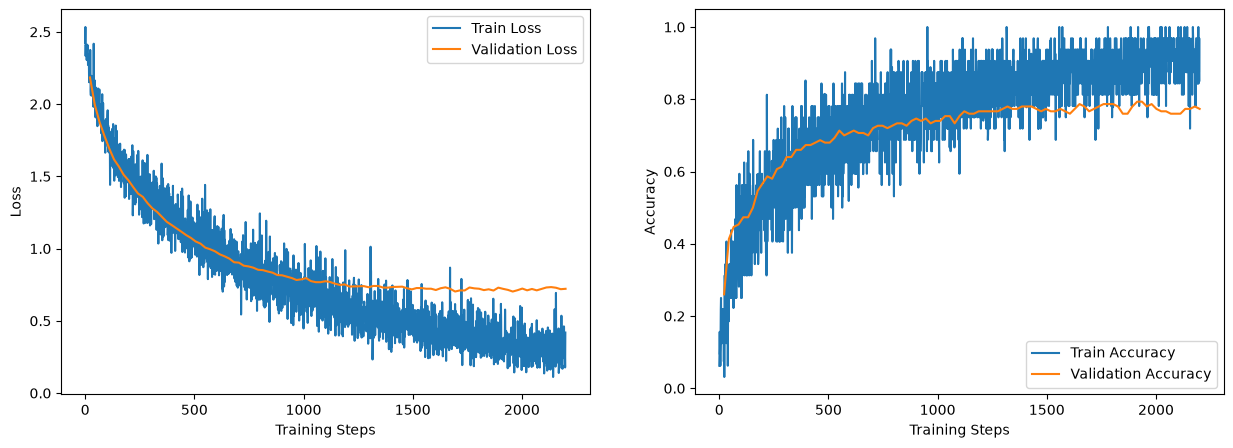

FCNN sa 93 feature-a
FCNN Test Results:
Accuracy:  0.7133
Precision: 0.7062
Recall:    0.7133
F1 Score:  0.7060


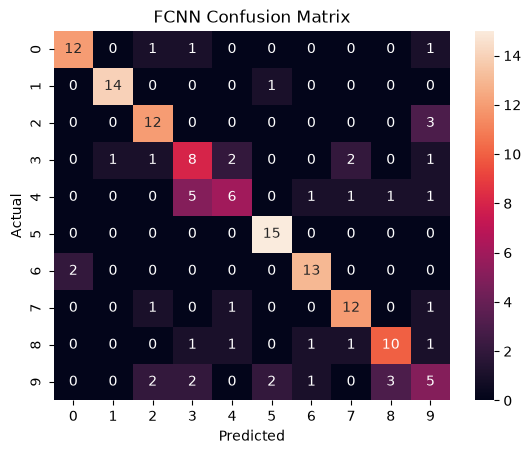

In [28]:
## FCNN SA 93 AUDIO KARAKTERISTIKE

X_train_93 = torch.tensor(features_train, dtype=torch.float32)
X_val_93 = torch.tensor(features_val, dtype=torch.float32)
X_test_93 = torch.tensor(features_test, dtype=torch.float32)

y_train_93 = torch.tensor(y_train, dtype=torch.long)
y_val_93 = torch.tensor(y_val, dtype=torch.long)
y_test_93 = torch.tensor(y_test, dtype=torch.long)

train_dataset_93 = TensorDataset(X_train_93, y_train_93)
val_dataset_93 = TensorDataset(X_val_93, y_val_93)
test_dataset_93 = TensorDataset(X_test_93, y_test_93)

train_loader_93 = DataLoader(
    train_dataset_93,
    batch_size=32,
    shuffle=True
)

validation_loader_93 = DataLoader(
    val_dataset_93,
    batch_size=32,
    shuffle=False
)

test_loader_93 = DataLoader(
    test_dataset_93,
    batch_size=32,
    shuffle=False
)


class MusicClassifier93(nn.Module):
    def __init__(self, number_of_classes=10):
        super(MusicClassifier93, self).__init__()

        self.fc1 = nn.Linear(93, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256, number_of_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)

        logits = self.fc4(x)
        probs = self.softmax(logits)

        return probs, logits


model_93 = MusicClassifier93(
    number_of_classes=10
)

model_93 = model_93.to(get_device())

optimizer_93 = torch.optim.Adam(
    model_93.parameters(),
    lr=0.0001
)

metrics_93 = train_model(
    model_93,
    optimizer_93,
    number_of_epochs=100,
    train_loader=train_loader_93,
    validation_loader=validation_loader_93
)

plot_metrics(metrics_93)

print("FCNN sa 93 feature-a")

_, fcnn_93_accuracy = evaluate_fcnn(
    model_93,
    test_loader_93
)

## PRIPREMA SPEKTROGRAMA ZA CNN

In [29]:
X_train_cnn = np.stack(train_df["spectrogram_fixed"].values)
X_val_cnn = np.stack(val_df["spectrogram_fixed"].values)
X_test_cnn = np.stack(test_df["spectrogram_fixed"].values)

X_train_cnn = X_train_cnn[:, np.newaxis, :, :]
X_val_cnn = X_val_cnn[:, np.newaxis, :, :]
X_test_cnn = X_test_cnn[:, np.newaxis, :, :]

print("CNN Train:", X_train_cnn.shape)
print("CNN Validation:", X_val_cnn.shape)
print("CNN Test:", X_test_cnn.shape)

CNN Train: (699, 1, 128, 1293)
CNN Validation: (150, 1, 128, 1293)
CNN Test: (150, 1, 128, 1293)


## DATASET ZA KOMBINOVANI CNN + FCNN MODEL

In [30]:
class MusicDataset(Dataset):

    def __init__(self, spectrograms, features, labels):
        self.spectrograms = torch.tensor(spectrograms, dtype=torch.float32)
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.spectrograms[index],
            self.features[index],
            self.labels[index]
        )

In [31]:
train_dataset = MusicDataset(
    X_train_cnn,
    features_train,
    y_train
)

val_dataset = MusicDataset(
    X_val_cnn,
    features_val,
    y_val
)

test_dataset = MusicDataset(
    X_test_cnn,
    features_test,
    y_test
)

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## CNN + FCNN MODEL

In [47]:
class CNN_FCNN_Classifier(nn.Module):

    def __init__(self, number_of_classes=10):
        super(CNN_FCNN_Classifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2)

        self.cnn_fc = nn.Linear(64 * 7 * 80, 100)

        self.fc1 = nn.Linear(93, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 100)

        self.combine_fc = nn.Linear(100 + 100, 256)
        self.fc4 = nn.Linear(256, number_of_classes)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, spectrogram, features):

        cnn = self.conv1(spectrogram)
        cnn = F.relu(cnn)
        cnn = self.pool(cnn)

        cnn = self.conv2(cnn)
        cnn = F.relu(cnn)
        cnn = self.pool(cnn)

        cnn = self.pool(cnn)
        cnn = self.pool(cnn)

        cnn = torch.flatten(cnn, 1)

        cnn = self.cnn_fc(cnn)
        cnn = F.relu(cnn)

        fc = self.fc1(features)
        fc = self.bn1(fc)
        fc = self.relu(fc)

        fc = self.fc2(fc)
        fc = self.bn2(fc)
        fc = self.relu(fc)

        fc = self.fc3(fc)
        fc = self.relu(fc)

        x = torch.cat((cnn, fc), dim=1)

        x = self.combine_fc(x)
        x = self.relu(x)

        logits = self.fc4(x)
        probs = self.softmax(logits)

        return probs, logits

In [48]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


number_of_classes = len(np.unique(y_train))

model2 = CNN_FCNN_Classifier(number_of_classes)
model2 = model2.to(get_device())

# print(model2)

In [49]:
optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=0.0001
)

## TRENIRANJE CNN + FCNN MODELA

In [50]:
def train_model_cnn_fcnn(model, optimizer, number_of_epochs, train_loader, validation_loader):

    metrics = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    device = get_device()

    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    for epoch in range(number_of_epochs):

        
        model.train()

        correct = 0
        total = 0
        loss_sum = 0

        for spectrograms, features, labels in train_loader:

            spectrograms = spectrograms.to(device)
            features = features.to(device)
            labels = labels.to(device)

            probs, logits = model(spectrograms, features)

            loss = nn.functional.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

            predicted = torch.argmax(probs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_accuracy = correct / total
        train_loss = loss_sum / len(train_loader)

        model.eval()

        correct = 0
        total = 0
        loss_sum = 0

        with torch.no_grad():

            for spectrograms, features, labels in validation_loader:

                spectrograms = spectrograms.to(device)
                features = features.to(device)
                labels = labels.to(device)

                probs, logits = model(spectrograms, features)

                loss = nn.functional.cross_entropy(logits, labels)

                loss_sum += loss.item()

                predicted = torch.argmax(probs, dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        val_loss = loss_sum / len(validation_loader)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

        metrics["train_loss"].append(train_loss)
        metrics["train_accuracy"].append(train_accuracy)
        metrics["val_loss"].append(val_loss)
        metrics["val_accuracy"].append(val_accuracy)

        print(
            "Epoch:", epoch + 1,
            "Train:", round(train_accuracy, 4),
            "Val:", round(val_accuracy, 4)
        )

    model.load_state_dict(best_model_state)

    print("\nBest validation accuracy:", best_val_accuracy)
    print("Best epoch:", best_epoch)

    return metrics

In [51]:
metrics2 = train_model_cnn_fcnn(
    model2,
    optimizer,
    30,
    train_loader,
    validation_loader
)

Epoch: 1 Train: 0.1001 Val: 0.16
Epoch: 2 Train: 0.1717 Val: 0.2
Epoch: 3 Train: 0.3119 Val: 0.34
Epoch: 4 Train: 0.4278 Val: 0.4133
Epoch: 5 Train: 0.4478 Val: 0.5
Epoch: 6 Train: 0.5479 Val: 0.56
Epoch: 7 Train: 0.5608 Val: 0.4533
Epoch: 8 Train: 0.6381 Val: 0.56
Epoch: 9 Train: 0.6896 Val: 0.5733
Epoch: 10 Train: 0.7282 Val: 0.5933
Epoch: 11 Train: 0.7597 Val: 0.6467
Epoch: 12 Train: 0.774 Val: 0.68
Epoch: 13 Train: 0.8112 Val: 0.6667
Epoch: 14 Train: 0.8283 Val: 0.7267
Epoch: 15 Train: 0.8598 Val: 0.7133
Epoch: 16 Train: 0.8727 Val: 0.6933
Epoch: 17 Train: 0.8755 Val: 0.6733
Epoch: 18 Train: 0.8984 Val: 0.7333
Epoch: 19 Train: 0.9242 Val: 0.72
Epoch: 20 Train: 0.9499 Val: 0.7667
Epoch: 21 Train: 0.9499 Val: 0.7733
Epoch: 22 Train: 0.9571 Val: 0.7533
Epoch: 23 Train: 0.9757 Val: 0.72
Epoch: 24 Train: 0.9871 Val: 0.6667
Epoch: 25 Train: 0.9814 Val: 0.7467
Epoch: 26 Train: 0.9886 Val: 0.7333
Epoch: 27 Train: 0.9928 Val: 0.7533
Epoch: 28 Train: 0.9914 Val: 0.7267
Epoch: 29 Train: 0.995

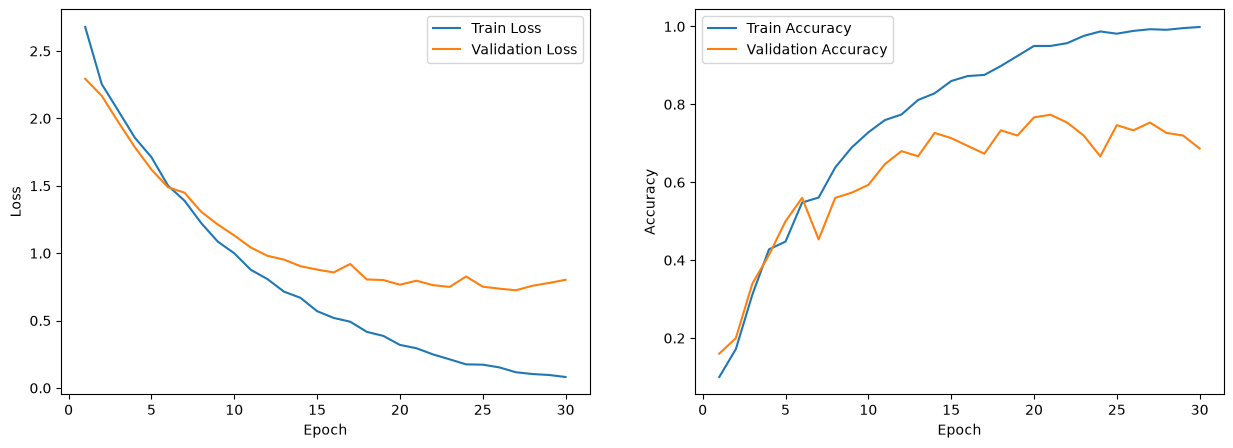

In [52]:
epochs = range(1, len(metrics2["train_loss"]) + 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, metrics2["train_loss"], label="Train Loss")
plt.plot(epochs, metrics2["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, metrics2["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, metrics2["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## EVALUACIJA CNN + FCNN MODELA

In [53]:
def evaluate_cnn_fcnn(model, dataloader):

    model.eval()

    predicted_labels = []
    true_labels = []

    device = get_device()

    with torch.no_grad():

        for spectrograms, features, labels in dataloader:

            spectrograms = spectrograms.to(device)
            features = features.to(device)
            labels = labels.to(device)

            probs, logits = model(spectrograms, features)

            predicted = torch.argmax(probs, dim=1)

            predicted_labels.extend(predicted.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(true_labels, predicted_labels)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="weighted"
    )

    print("Test Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=genres,
        yticklabels=genres
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("CNN + FCNN Confusion Matrix")
    plt.show()

    return accuracy, precision, recall, f1
# Konačna evaluacija na test skupu

Test Results:
Accuracy:  0.7400
Precision: 0.7550
Recall:    0.7400
F1 Score:  0.7326


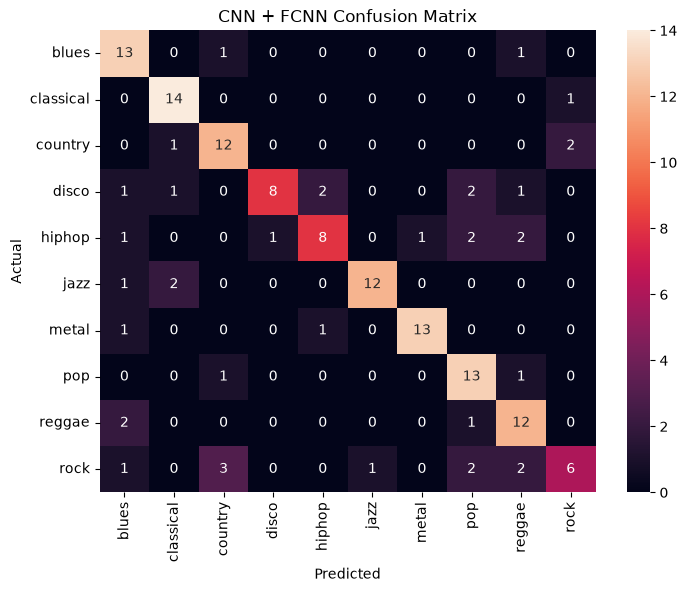

In [54]:
cnn_fcnn_accuracy, cnn_fcnn_precision, cnn_fcnn_recall, cnn_fcnn_f1 = \
    evaluate_cnn_fcnn(model2, test_loader)

##  POREĐENJE MODELA

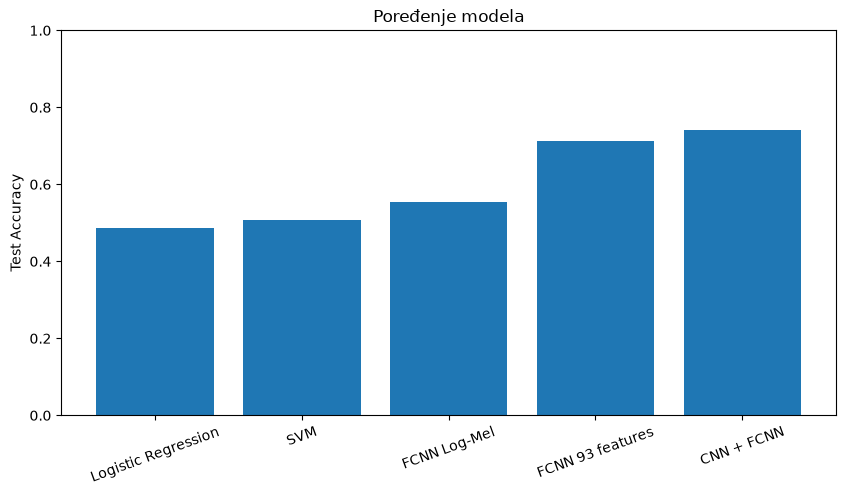

In [55]:
model_names = [
    "Logistic Regression",
    "SVM",
    "FCNN Log-Mel",
    "FCNN 93 features",
    "CNN + FCNN"
]

accuracies = [
    lr_accuracy,
    svm_accuracy,
    fcnn_accuracy,
    fcnn_93_accuracy,
    cnn_fcnn_accuracy
]

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies)
plt.ylabel("Test Accuracy")
plt.title("Poređenje modela")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [56]:
import joblib
joblib.dump(logistic_model, "logistic_model.pkl")
joblib.dump(best_svm, "svm_model.pkl")

joblib.dump(scaler, "spectrogram_scaler.pkl")
joblib.dump(scaler_features, "features_scaler.pkl")

torch.save(model.state_dict(), "fcnn_model.pth")
torch.save(model2.state_dict(), "cnn_fcnn_model.pth")
torch.save(model_93.state_dict(), "fcnn_93_features_model.pth")


## Zaključak


U projektu je upoređeno pet pristupa klasifikaciji muzičkih žanrova. Klasični modeli i FCNN nad direktno spljoštenim log-Mel spektrogramima ostvarili su slabije rezultate. FCNN nad 93 izdvojene audio karakteristike ostvario je znatno bolje rezultate, dok je kombinovani CNN + FCNN model ostvario najbolju test tačnost od 74%. Time se pokazalo da kombinovanje informacija iz log-Mel spektrograma i izdvojenih audio karakteristika može poboljšati klasifikaciju. Rezultati takođe pokazuju izražen overfitting kod FCNN modela nad visokodimenzionalnim spljoštenim spektrogramima.